In [1]:
import graphviz
import json




In [23]:
# Open and read the JSON file
with open('onthology_extended.json', 'r') as file:
    ontology = json.load(file)

In [28]:
ontology=ontology['graphs'][0]

In [29]:
ontology

{'id': 'http://purl.obolibrary.org/obo/go.owl',
 'meta': {'basicPropertyValues': [{'pred': 'http://purl.obolibrary.org/obo/IAO_0000700',
    'val': 'http://purl.obolibrary.org/obo/GO_0003674'},
   {'pred': 'http://purl.obolibrary.org/obo/IAO_0000700',
    'val': 'http://purl.obolibrary.org/obo/GO_0005575'},
   {'pred': 'http://purl.obolibrary.org/obo/IAO_0000700',
    'val': 'http://purl.obolibrary.org/obo/GO_0008150'},
   {'pred': 'http://purl.org/dc/elements/1.1/description',
    'val': 'The Gene Ontology (GO) provides a framework and set of concepts for describing the functions of gene products from all organisms.'},
   {'pred': 'http://purl.org/dc/elements/1.1/title', 'val': 'Gene Ontology'},
   {'pred': 'http://purl.org/dc/terms/license',
    'val': 'http://creativecommons.org/licenses/by/4.0/'},
   {'pred': 'http://www.geneontology.org/formats/oboInOwl#default-namespace',
    'val': 'gene_ontology'},
   {'pred': 'http://www.geneontology.org/formats/oboInOwl#hasOBOFormatVersion',


In [18]:
def get_node_info(node):
    node_name = list(node.keys())[0]
    node_data = node[node_name]['data']
    node_children = node[node_name].get('children', None)
    return node_name, node_data, node_children


In [19]:

traversed_nodes = [ontology] # start with root node

# initialize the graph 
f = graphviz.Digraph('finite_state_machine', filename='fsm.gv')
f.attr(rankdir='LR', size='8,5')
f.attr('node', shape='rectangle')

while (len(traversed_nodes) > 0):
    cur_node = traversed_nodes.pop(0)
    cur_node_name, cur_node_data, cur_node_children = get_node_info(cur_node)
    if (cur_node_children is not None): # check if the cur_node has a child
        for next_node in cur_node_children: 
            traversed_nodes.append(next_node)
            next_node_name = get_node_info(next_node)[0]
            f.edge(cur_node_name, next_node_name, label='') # add edge to the graph
f.view()

TypeError: string indices must be integers, not 'str'

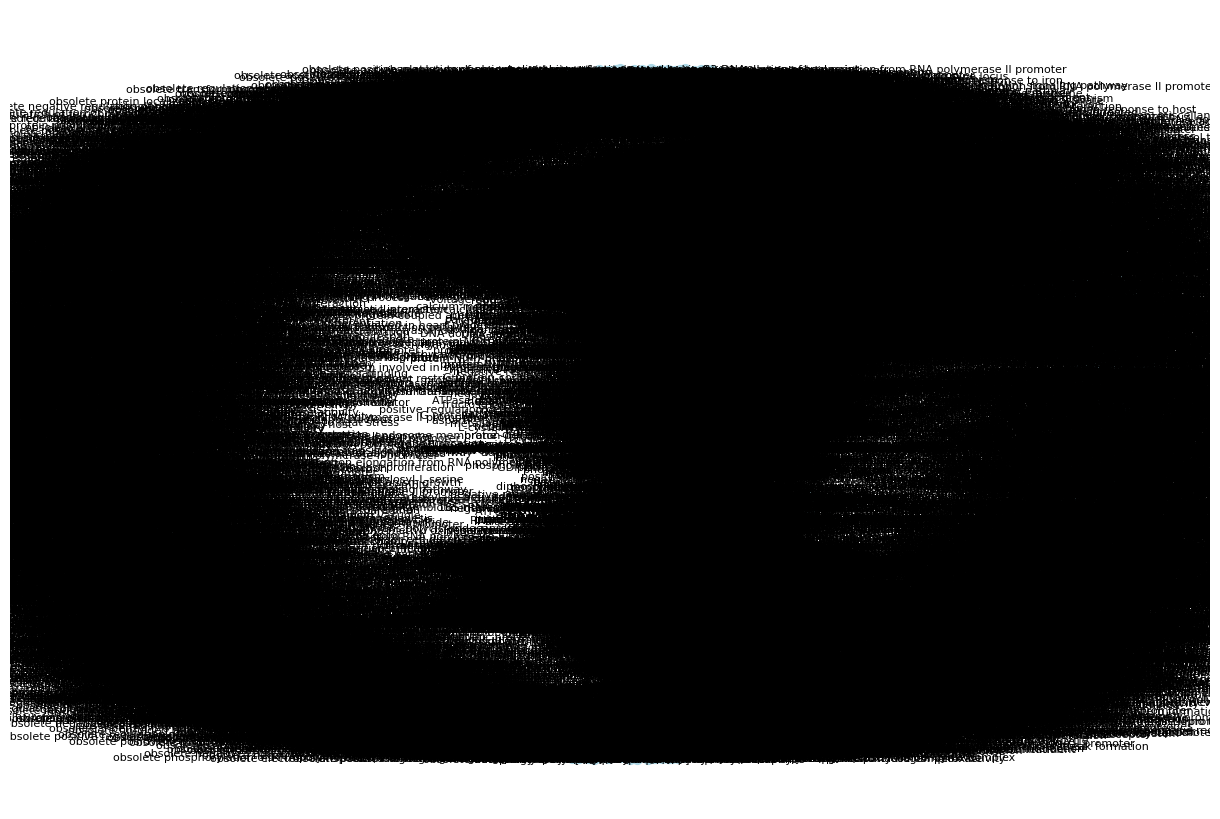

In [27]:
import json
import networkx as nx
import matplotlib.pyplot as plt



# Create Graph
G = nx.DiGraph()
for node in data["graphs"][0]["nodes"]:
    G.add_node(node["id"], label=node.get("lbl", ""))

for edge in data["graphs"][0].get("edges", []):
    G.add_edge(edge["sub"], edge["obj"], label=edge["pred"])

# Draw Graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=False, node_color="lightblue", edge_color="gray", node_size=50)
labels = {node["id"]: node.get("lbl", "") for node in data["graphs"][0]["nodes"]}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.show()
